REALIZADO POR: TANIA PAMELA APAZA VILCA

In [1]:

# ============================================
# CELDA 1: IMPORTAR LIBRERÍAS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Algoritmos de clustering
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering

# Métricas de validación externa
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score
)

# Métricas de validación interna
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

print("¡Librerías importadas correctamente!")

¡Librerías importadas correctamente!


Primeras 5 filas del dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Cantidad de flores: 150
Cantidad de características: 4

Cantidad de flores por especie:
Especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


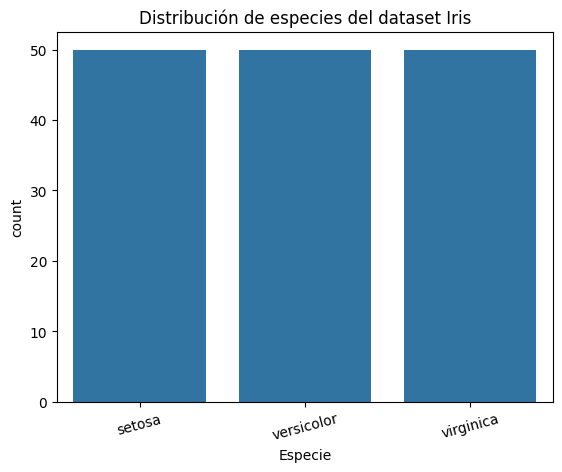

In [2]:

# ============================================
# CELDA 2: CARGAR DATASET IRIS
# ============================================

# Cargar el dataset Iris
iris = load_iris()

# X contiene las 4 características de las flores
X = iris.data

# y contiene las especies reales (solo para evaluar)
y = iris.target

# Crear un DataFrame para visualizar los datos
df = pd.DataFrame(X, columns=iris.feature_names)
df["Especie"] = iris.target_names[y]

# Mostrar las primeras filas
print("Primeras 5 filas del dataset:")
display(df.head())

# Mostrar dimensiones
print("Cantidad de flores:", X.shape[0])
print("Cantidad de características:", X.shape[1])

# Mostrar cantidad por especie
print("\nCantidad de flores por especie:")
print(df["Especie"].value_counts())

# Visualizar distribución de las especies
sns.countplot(data=df, x="Especie")
plt.title("Distribución de especies del dataset Iris")
plt.xticks(rotation=15)
plt.show()

In [3]:

# ============================================
# CELDA 3: PREPROCESAMIENTO
# ============================================

# Estandarizar las 4 características
# Esto evita que una característica domine
# el cálculo de distancias por su escala.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos estandarizados correctamente.")

# Reducir a 2 dimensiones SOLO para las gráficas
# Los modelos seguirán utilizando las 4 características.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por PCA:",
      round(sum(pca.explained_variance_ratio_) * 100, 2), "%")

Datos estandarizados correctamente.
Varianza explicada por PCA: 95.81 %


In [4]:

# ============================================
# CELDA 4: ENTRENAMIENTO DE MODELOS
# ============================================

# 1. K-MEANS
# Se especifican 3 clusters porque Iris tiene
# 3 especies conocidas. No se usan las etiquetas
# reales para entrenar.

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_scaled)


# 2. DBSCAN
# eps: distancia máxima para considerar vecinos.
# min_samples: mínimo de puntos para formar
# una región densa.

dbscan = DBSCAN(
    eps=0.7,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X_scaled)


# 3. SPECTRAL CLUSTERING
# Se solicita encontrar 3 grupos.
# nearest_neighbors construye un grafo de vecinos.

spectral = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=42,
    assign_labels="kmeans"
)

labels_spectral = spectral.fit_predict(X_scaled)


# Guardar los resultados
resultados = {
    "K-means": labels_kmeans,
    "DBSCAN": labels_dbscan,
    "SpectralClustering": labels_spectral
}

print("¡Los tres modelos fueron entrenados!")

# Mostrar cantidad de clusters encontrados
for nombre, etiquetas in resultados.items():
    clusters = set(etiquetas) - {-1}
    ruido = list(etiquetas).count(-1)

    print(f"\n{nombre}")
    print("Clusters encontrados:", len(clusters))
    print("Puntos considerados ruido:", ruido)

¡Los tres modelos fueron entrenados!

K-means
Clusters encontrados: 3
Puntos considerados ruido: 0

DBSCAN
Clusters encontrados: 2
Puntos considerados ruido: 6

SpectralClustering
Clusters encontrados: 3
Puntos considerados ruido: 0


In [5]:

# ============================================
# CELDA 5: EVALUACIÓN DE LOS MODELOS
# ============================================

resultados_metricas = []

for nombre, etiquetas in resultados.items():

    # -------------------------------
    # MÉTRICAS DE VALIDACIÓN EXTERNA
    # Comparan clusters con especies reales
    # -------------------------------

    ari = adjusted_rand_score(y, etiquetas)
    nmi = normalized_mutual_info_score(y, etiquetas)
    homogeneidad = homogeneity_score(y, etiquetas)

    # -------------------------------
    # MÉTRICAS DE VALIDACIÓN INTERNA
    # Se excluye el ruido de DBSCAN (-1)
    # para evaluar los grupos identificados.
    # -------------------------------

    if nombre == "DBSCAN":
        mascara = etiquetas != -1
        X_eval = X_scaled[mascara]
        labels_eval = etiquetas[mascara]
    else:
        X_eval = X_scaled
        labels_eval = etiquetas

    # Deben existir al menos 2 clusters
    # y menos clusters que muestras para
    # calcular las métricas internas.

    n_clusters = len(set(labels_eval))

    if 2 <= n_clusters < len(labels_eval):

        sil = silhouette_score(X_eval, labels_eval)
        db = davies_bouldin_score(X_eval, labels_eval)
        ch = calinski_harabasz_score(X_eval, labels_eval)

    else:
        sil = np.nan
        db = np.nan
        ch = np.nan

    resultados_metricas.append({
        "Modelo": nombre,
        "Clusters": len(set(etiquetas) - {-1}),
        "Ruido": np.sum(etiquetas == -1),
        "ARI": ari,
        "NMI": nmi,
        "Homogeneidad": homogeneidad,
        "Silhouette": sil,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch
    })


# Crear tabla comparativa
tabla_resultados = pd.DataFrame(resultados_metricas)

# Redondear valores para una mejor lectura
display(tabla_resultados.round(4))

,Modelo,Clusters,Ruido,ARI,NMI,Homogeneidad,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-means,3,0,0.6201,0.6595,0.6591,0.4599,0.8336,241.9044
1,DBSCAN,2,6,0.5401,0.6712,0.5735,0.6018,0.5568,281.7393
2,SpectralClustering,3,0,0.6465,0.6838,0.6737,0.4593,0.8224,229.6799


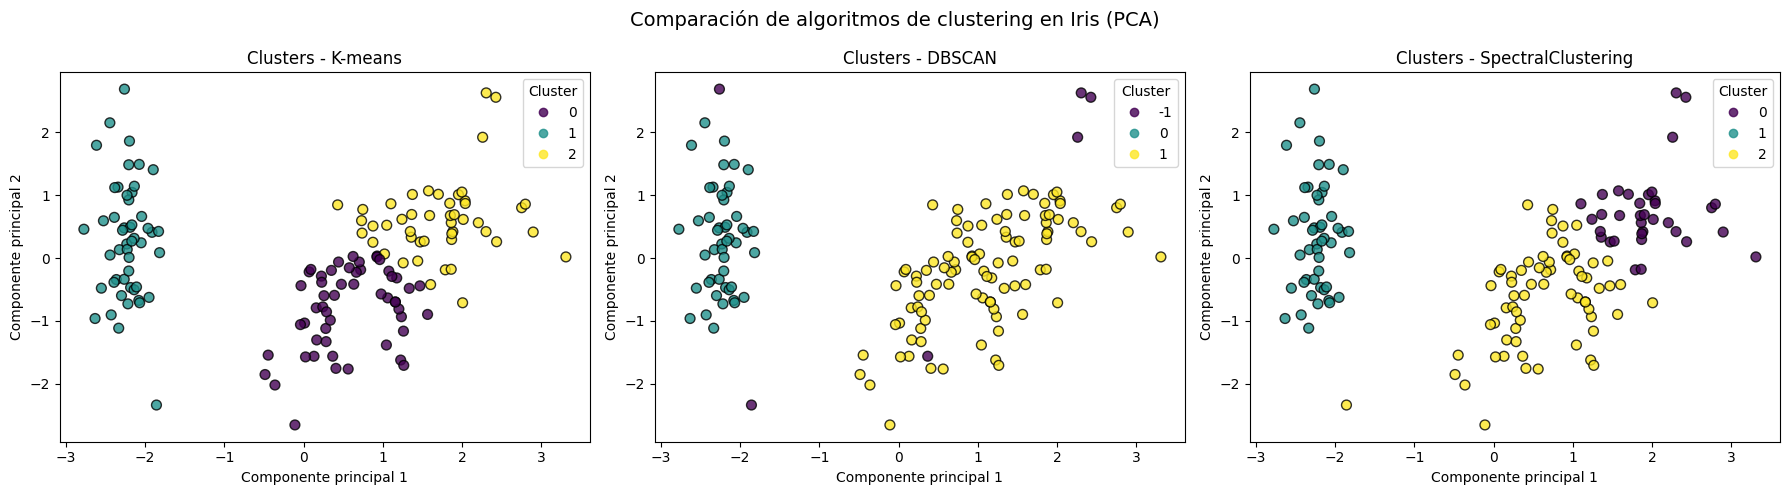

In [6]:

# ============================================
# CELDA 6: VISUALIZACIÓN DE CLUSTERS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, etiquetas) in zip(axes, resultados.items()):

    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=etiquetas,
        cmap="viridis",
        s=50,
        edgecolor="black",
        alpha=0.8
    )

    ax.set_title(f"Clusters - {nombre}")
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")

    # Leyenda de clusters
    handles, _ = scatter.legend_elements()
    ax.legend(handles, sorted(set(etiquetas)),
              title="Cluster")

plt.suptitle(
    "Comparación de algoritmos de clustering en Iris (PCA)",
    fontsize=14
)

plt.tight_layout()
plt.show()

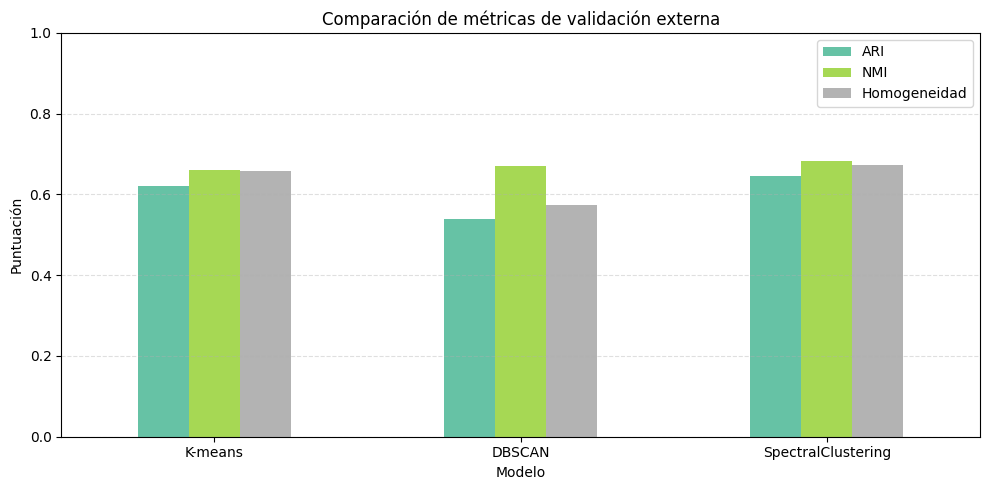

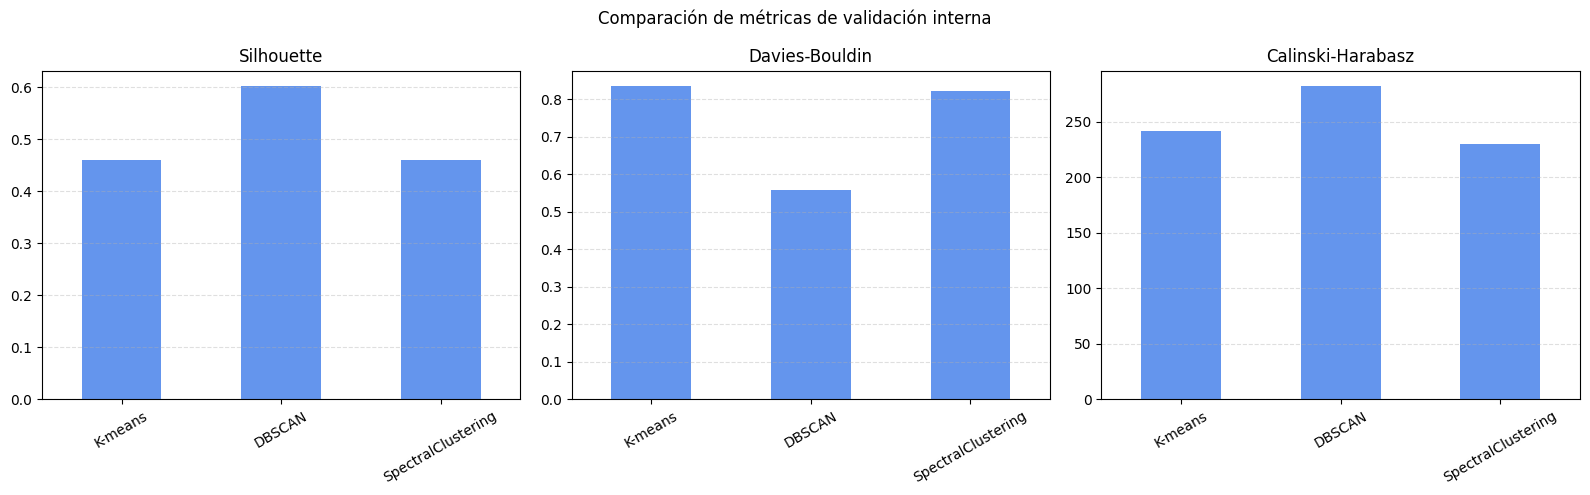

In [7]:

# ============================================
# CELDA 7: COMPARACIÓN DE MÉTRICAS
# ============================================

metricas_externas = ["ARI", "NMI", "Homogeneidad"]

metricas_internas = [
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz"
]

# -------------------------------
# GRÁFICAS DE MÉTRICAS EXTERNAS
# -------------------------------

tabla_resultados.set_index("Modelo")[metricas_externas].plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1),
    colormap="Set2"
)

plt.title("Comparación de métricas de validación externa")
plt.ylabel("Puntuación")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc="best")
plt.tight_layout()
plt.show()


# -------------------------------
# GRÁFICAS DE MÉTRICAS INTERNAS
# -------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metrica in zip(axes, metricas_internas):

    tabla_resultados.plot(
        x="Modelo",
        y=metrica,
        kind="bar",
        ax=ax,
        legend=False,
        color="cornflowerblue"
    )

    ax.set_title(metrica)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Comparación de métricas de validación interna")
plt.tight_layout()
plt.show()

b.	Use el dataset sintético moons y entrene los modelos K-means, DBSCAN y SpectralClustering y aplique métricas de validación externa e interna.

In [8]:

# ============================================
# CELDA 1: IMPORTAR LIBRERÍAS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# Algoritmos de clustering
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering

# Métricas externas
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score
)

# Métricas internas
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

sns.set_theme(style="whitegrid")

print("¡Librerías importadas correctamente!")

¡Librerías importadas correctamente!


Cantidad de muestras: 500
Cantidad de características: 2
Cantidad de grupos reales: 2


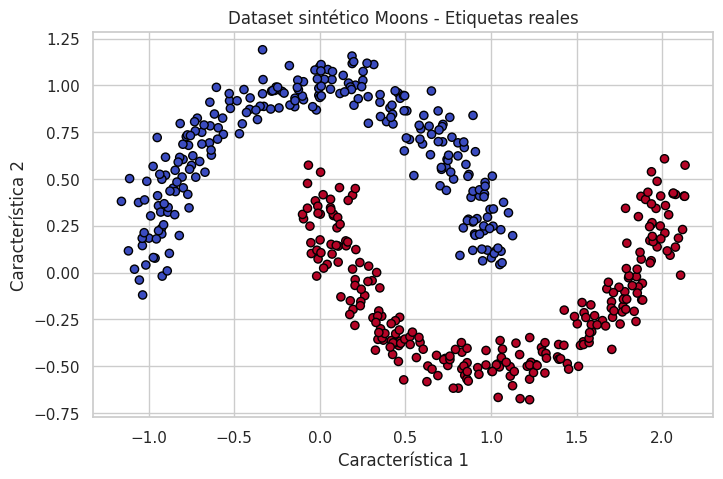

In [9]:

# ============================================
# CELDA 2: GENERAR DATASET MOONS
# ============================================

# Generar 500 muestras con dos grupos en forma
# de medias lunas.
# y contiene las etiquetas reales (solo evaluación).

X, y = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=42
)

print("Cantidad de muestras:", X.shape[0])
print("Cantidad de características:", X.shape[1])
print("Cantidad de grupos reales:", len(np.unique(y)))

# Graficar los datos originales
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm",
    s=35,
    edgecolor="black"
)

plt.title("Dataset sintético Moons - Etiquetas reales")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

In [10]:

# ============================================
# CELDA 3: ESTANDARIZACIÓN
# ============================================

# Estandarizar las características para que
# tengan una escala comparable.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos estandarizados correctamente.")

Datos estandarizados correctamente.


In [11]:

# ============================================
# CELDA 4: ENTRENAMIENTO DE LOS MODELOS
# ============================================

# 1. K-MEANS
# Busca 2 clusters, pero no considera
# directamente las formas curvas.

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_scaled)


# 2. DBSCAN
# Agrupa puntos según su densidad.
# eps y min_samples controlan la formación
# de clusters y la detección de ruido.

dbscan = DBSCAN(
    eps=0.25,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X_scaled)


# 3. SPECTRAL CLUSTERING
# Utiliza relaciones de vecindad para
# detectar estructuras no lineales.

spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=42,
    assign_labels="kmeans"
)

labels_spectral = spectral.fit_predict(X_scaled)


# Guardar las etiquetas de cada modelo
resultados = {
    "K-means": labels_kmeans,
    "DBSCAN": labels_dbscan,
    "SpectralClustering": labels_spectral
}

print("¡Entrenamiento completado!")

for nombre, etiquetas in resultados.items():
    clusters = set(etiquetas) - {-1}
    ruido = np.sum(etiquetas == -1)

    print(f"\n{nombre}")
    print("Clusters encontrados:", len(clusters))
    print("Puntos de ruido:", ruido)

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


¡Entrenamiento completado!

K-means
Clusters encontrados: 2
Puntos de ruido: 0

DBSCAN
Clusters encontrados: 2
Puntos de ruido: 0

SpectralClustering
Clusters encontrados: 2
Puntos de ruido: 0


In [12]:

# ============================================
# CELDA 5: EVALUACIÓN DE LOS MODELOS
# ============================================

resultados_metricas = []

for nombre, etiquetas in resultados.items():

    # MÉTRICAS EXTERNAS
    # Comparan los clusters con las etiquetas reales.

    ari = adjusted_rand_score(y, etiquetas)
    nmi = normalized_mutual_info_score(y, etiquetas)
    homogeneidad = homogeneity_score(y, etiquetas)

    # MÉTRICAS INTERNAS
    # Para DBSCAN se excluyen los puntos de ruido.

    if nombre == "DBSCAN":
        mascara = etiquetas != -1
        X_eval = X_scaled[mascara]
        labels_eval = etiquetas[mascara]
    else:
        X_eval = X_scaled
        labels_eval = etiquetas

    n_clusters = len(set(labels_eval))

    # Se necesitan al menos 2 clusters
    # y menos clusters que muestras.

    if 2 <= n_clusters < len(labels_eval):

        sil = silhouette_score(X_eval, labels_eval)
        db = davies_bouldin_score(X_eval, labels_eval)
        ch = calinski_harabasz_score(X_eval, labels_eval)

    else:
        sil = np.nan
        db = np.nan
        ch = np.nan

    resultados_metricas.append({
        "Modelo": nombre,
        "Clusters": len(set(etiquetas) - {-1}),
        "Ruido": np.sum(etiquetas == -1),
        "ARI": ari,
        "NMI": nmi,
        "Homogeneidad": homogeneidad,
        "Silhouette": sil,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch
    })


# Crear tabla comparativa
tabla_resultados = pd.DataFrame(resultados_metricas)

print("TABLA DE MÉTRICAS DE VALIDACIÓN")
display(tabla_resultados.round(4))

TABLA DE MÉTRICAS DE VALIDACIÓN


,Modelo,Clusters,Ruido,ARI,NMI,Homogeneidad,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-means,2,0,0.4451,0.3515,0.3515,0.4932,0.8132,690.2079
1,DBSCAN,2,0,1.0000,1.0000,1.0000,0.3836,1.0241,430.8867
2,SpectralClustering,2,0,1.0000,1.0000,1.0000,0.3836,1.0241,430.8867


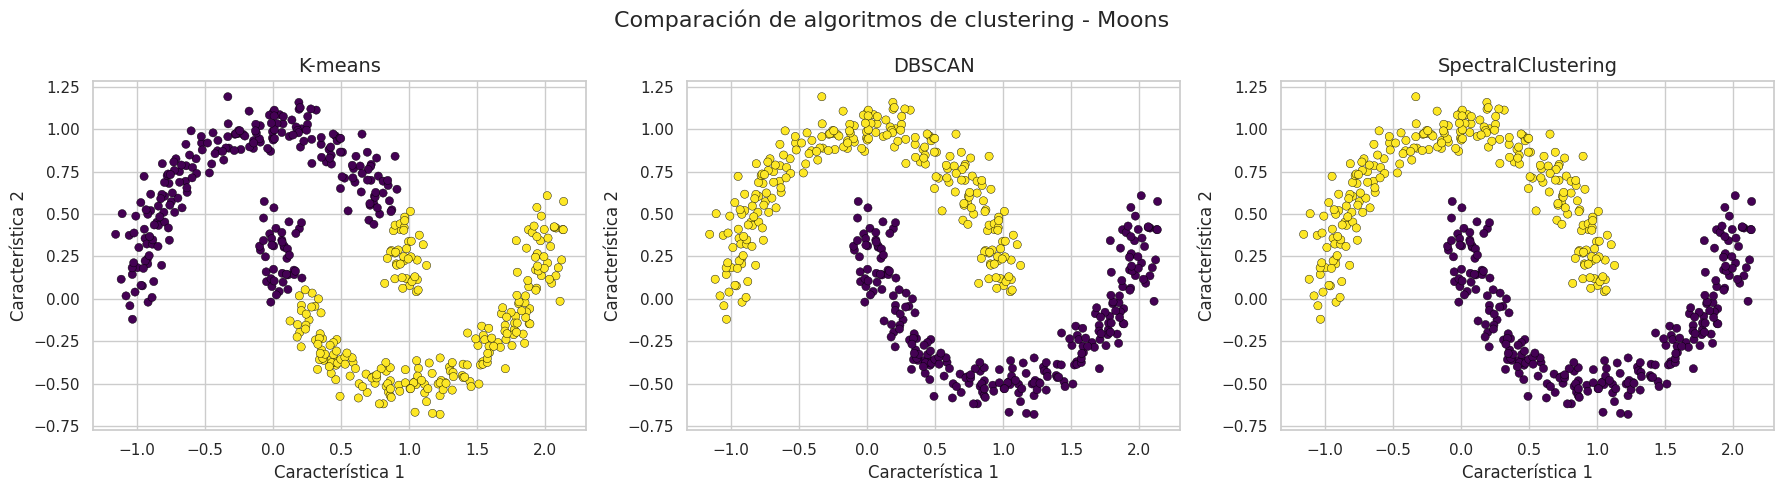

In [13]:

# ============================================
# CELDA 6: GRÁFICAS DE CLUSTERS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, etiquetas) in zip(axes, resultados.items()):

    # Colorear cada punto según el cluster asignado
    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=etiquetas,
        cmap="viridis",
        s=35,
        edgecolor="black",
        linewidth=0.3
    )

    ax.set_title(nombre, fontsize=14)
    ax.set_xlabel("Característica 1")
    ax.set_ylabel("Característica 2")

plt.suptitle("Comparación de algoritmos de clustering - Moons",
             fontsize=16)

plt.tight_layout()
plt.show()

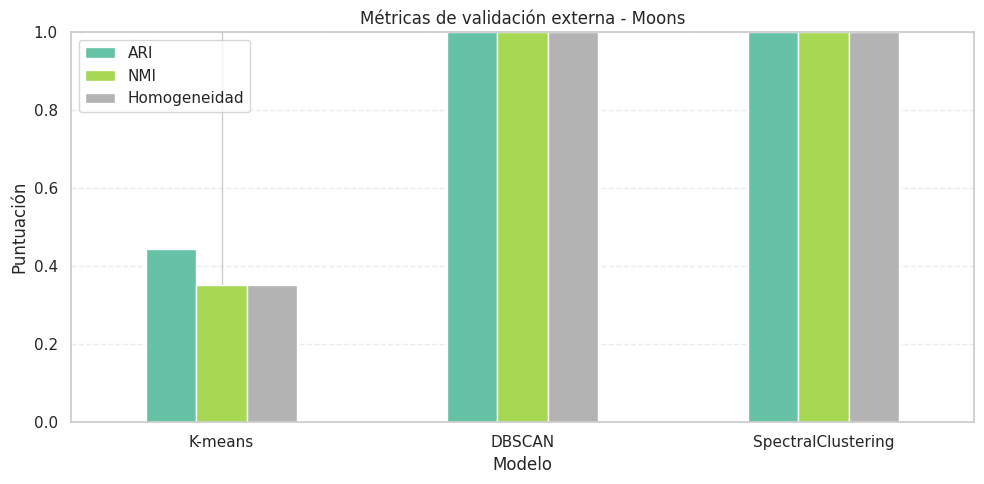

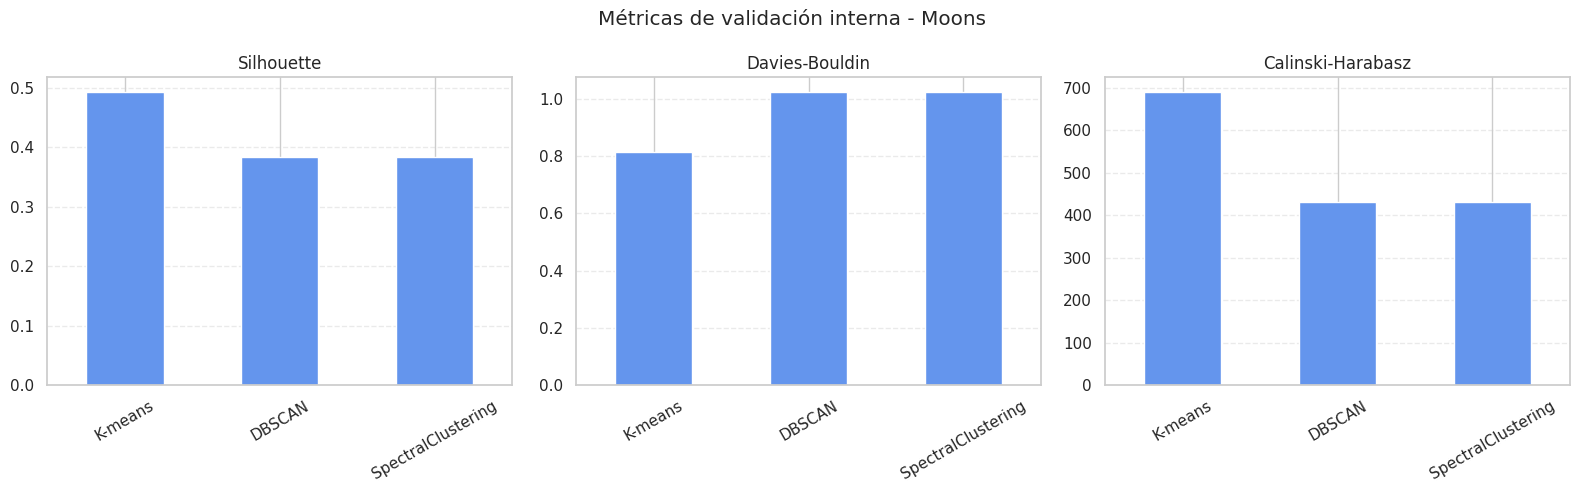

In [14]:

# ============================================
# CELDA 7: COMPARACIÓN DE MÉTRICAS
# ============================================

# MÉTRICAS EXTERNAS
metricas_externas = ["ARI", "NMI", "Homogeneidad"]

tabla_resultados.set_index("Modelo")[metricas_externas].plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1),
    colormap="Set2"
)

plt.title("Métricas de validación externa - Moons")
plt.ylabel("Puntuación")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# MÉTRICAS INTERNAS
metricas_internas = [
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz"
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metrica in zip(axes, metricas_internas):

    tabla_resultados.plot(
        x="Modelo",
        y=metrica,
        kind="bar",
        ax=ax,
        legend=False,
        color="cornflowerblue"
    )

    ax.set_title(metrica)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Métricas de validación interna - Moons")
plt.tight_layout()
plt.show()

c.	Use el dataset sintético circle y entren los modelos K-means, DBSCAN y SpectralClustering y aplique métricas de validación externa e interna.

In [15]:
# ============================================
# 1. IMPORTAR LIBRERÍAS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles

from sklearn.cluster import KMeans, DBSCAN, SpectralClustering

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [16]:
# ============================================
# 2. CREAR DATASET SINTÉTICO CIRCLE
# ============================================

X, y_real = make_circles(
    n_samples=1000,
    noise=0.05,
    factor=0.5,
    random_state=42
)

print("Cantidad de datos:", X.shape[0])
print("Cantidad de características:", X.shape[1])
print("Cantidad de clases reales:", len(np.unique(y_real)))

Cantidad de datos: 1000
Cantidad de características: 2
Cantidad de clases reales: 2


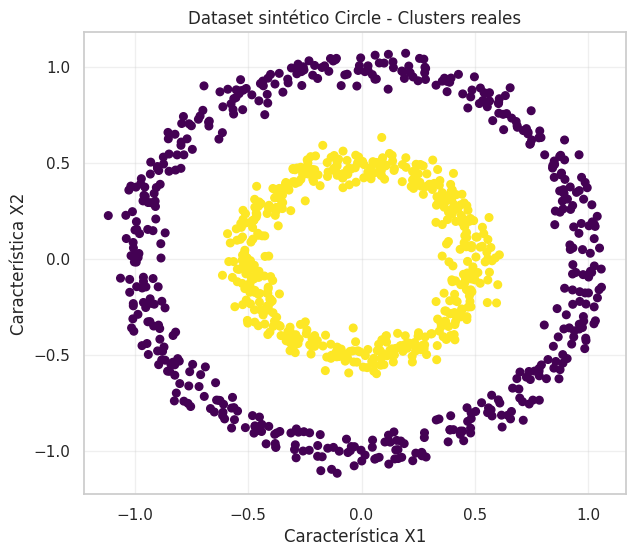

In [17]:
# ============================================
# 3. VISUALIZAR LOS DATOS REALES
# ============================================

plt.figure(figsize=(7, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_real,
    cmap="viridis",
    s=30
)

plt.title("Dataset sintético Circle - Clusters reales")
plt.xlabel("Característica X1")
plt.ylabel("Característica X2")
plt.grid(alpha=0.3)

plt.show()

K-Means entrenado correctamente.


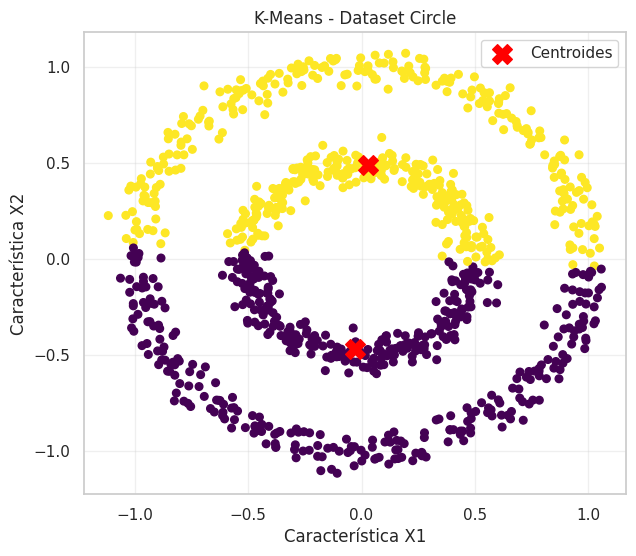

In [18]:
# ============================================
# 4. K-MEANS
# ============================================

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

y_kmeans = kmeans.fit_predict(X)

print("K-Means entrenado correctamente.")

# ============================================
# 4.1 GRÁFICA K-MEANS
# ============================================

plt.figure(figsize=(7, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_kmeans,
    cmap="viridis",
    s=30
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Centroides"
)

plt.title("K-Means - Dataset Circle")
plt.xlabel("Característica X1")
plt.ylabel("Característica X2")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

DBSCAN entrenado correctamente.
Clusters encontrados: [0 1]


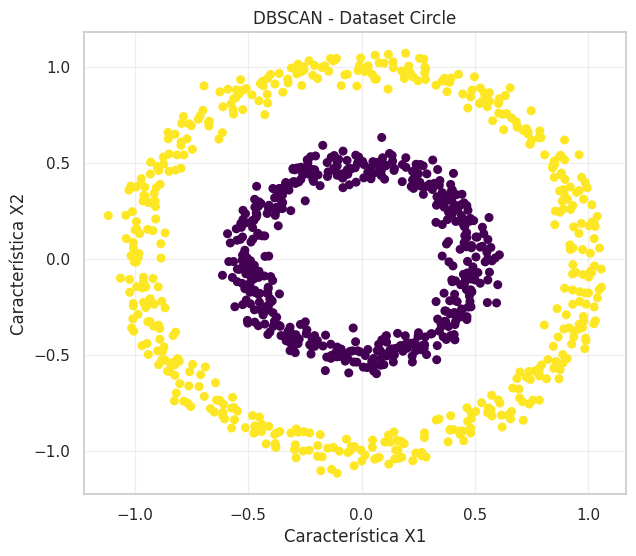

In [19]:
# ============================================
# 5. DBSCAN
# ============================================

dbscan = DBSCAN(
    eps=0.15,
    min_samples=5
)

y_dbscan = dbscan.fit_predict(X)

print("DBSCAN entrenado correctamente.")
print("Clusters encontrados:", np.unique(y_dbscan))

# ============================================
# 5.1 GRÁFICA DBSCAN
# ============================================

plt.figure(figsize=(7, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_dbscan,
    cmap="viridis",
    s=30
)

plt.title("DBSCAN - Dataset Circle")
plt.xlabel("Característica X1")
plt.ylabel("Característica X2")
plt.grid(alpha=0.3)

plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Spectral Clustering entrenado correctamente.


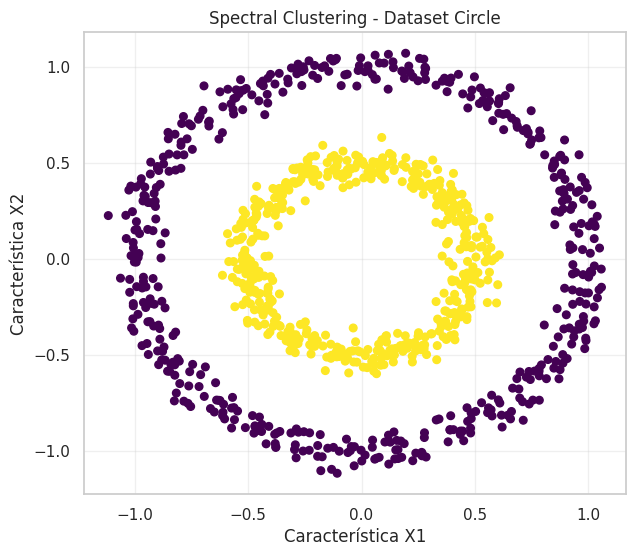

In [20]:
# ============================================
# 6. SPECTRAL CLUSTERING
# ============================================

spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=42
)

y_spectral = spectral.fit_predict(X)

print("Spectral Clustering entrenado correctamente.")

# ============================================
# 6.1 GRÁFICA SPECTRAL CLUSTERING
# ============================================

plt.figure(figsize=(7, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_spectral,
    cmap="viridis",
    s=30
)

plt.title("Spectral Clustering - Dataset Circle")
plt.xlabel("Característica X1")
plt.ylabel("Característica X2")
plt.grid(alpha=0.3)

plt.show()

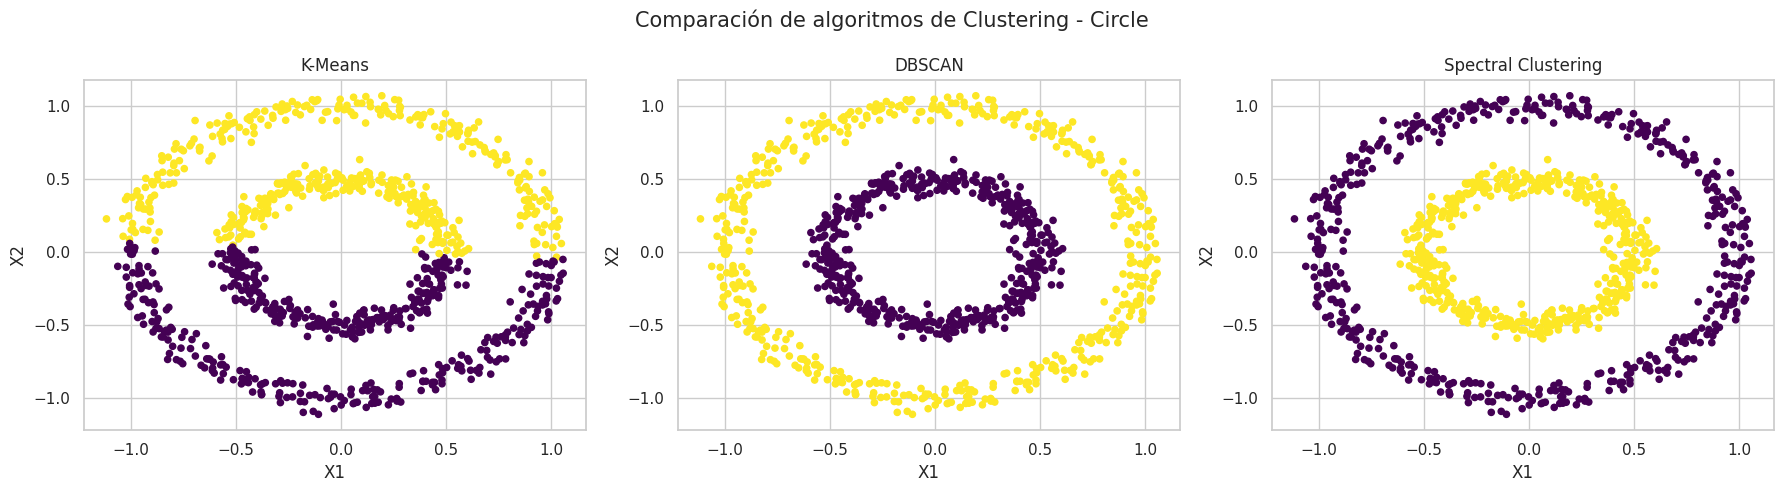

In [21]:
# ============================================
# 7. COMPARACIÓN DE LOS TRES MODELOS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=y_kmeans,
    cmap="viridis",
    s=20
)
axes[0].set_title("K-Means")
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")

# DBSCAN
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=y_dbscan,
    cmap="viridis",
    s=20
)
axes[1].set_title("DBSCAN")
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")

# Spectral
axes[2].scatter(
    X[:, 0],
    X[:, 1],
    c=y_spectral,
    cmap="viridis",
    s=20
)
axes[2].set_title("Spectral Clustering")
axes[2].set_xlabel("X1")
axes[2].set_ylabel("X2")

plt.suptitle("Comparación de algoritmos de Clustering - Circle", fontsize=15)

plt.tight_layout()
plt.show()

In [22]:
# ============================================
# 8. MÉTRICAS EXTERNAS
# ============================================

modelos = {
    "K-Means": y_kmeans,
    "DBSCAN": y_dbscan,
    "Spectral Clustering": y_spectral
}

resultados_externos = []

for nombre, etiquetas in modelos.items():

    resultados_externos.append({
        "Modelo": nombre,
        "ARI": adjusted_rand_score(y_real, etiquetas),
        "NMI": normalized_mutual_info_score(y_real, etiquetas),
        "Homogeneidad": homogeneity_score(y_real, etiquetas)
    })

df_externas = pd.DataFrame(resultados_externos)

df_externas

,Modelo,ARI,NMI,Homogeneidad
0,K-Means,-0.000998,0.000003,0.000003
1,DBSCAN,1.000000,1.000000,1.000000
2,Spectral Clustering,1.000000,1.000000,1.000000


In [23]:
# ============================================
# 9. MÉTRICAS INTERNAS
# ============================================

resultados_internos = []

for nombre, etiquetas in modelos.items():

    # Verificar que exista más de un cluster
    clusters_validos = np.unique(etiquetas)

    if len(clusters_validos) > 1:

        silhouette = silhouette_score(X, etiquetas)
        davies = davies_bouldin_score(X, etiquetas)
        calinski = calinski_harabasz_score(X, etiquetas)

    else:
        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    resultados_internos.append({
        "Modelo": nombre,
        "Silhouette": silhouette,
        "Davies-Bouldin": davies,
        "Calinski-Harabasz": calinski
    })

df_internas = pd.DataFrame(resultados_internos)

df_internas

,Modelo,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.354149,1.182506,577.742349
1,DBSCAN,0.112462,894.129425,0.001122
2,Spectral Clustering,0.112462,894.129425,0.001122


In [24]:
# ============================================
# 10. TABLA FINAL DE RESULTADOS
# ============================================

df_resultados = pd.merge(
    df_externas,
    df_internas,
    on="Modelo"
)

df_resultados

,Modelo,ARI,NMI,Homogeneidad,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,-0.000998,0.000003,0.000003,0.354149,1.182506,577.742349
1,DBSCAN,1.000000,1.000000,1.000000,0.112462,894.129425,0.001122
2,Spectral Clustering,1.000000,1.000000,1.000000,0.112462,894.129425,0.001122
